In [1]:
# 1. FORCE UNINSTALL everything that could conflict
!pip uninstall -y mediapipe protobuf numpy tensorflow jax jaxlib

# 2. INSTALL THE "STABLE TRIO"
# We force NumPy to be 1.26.4 (The last stable version before 2.0)
# We force MediaPipe to 0.10.14 (Stable version)
# We allow pip to find the correct protobuf (usually 4.25.x)
!pip install "numpy==1.26.4" "mediapipe==0.10.14" --force-reinstall

# 3. CRITICAL: CHECK VERSIONS
import numpy as np
import mediapipe as mp

print(f"NumPy Version: {np.__version__}")     # MUST BE 1.26.4
print(f"MediaPipe Version: {mp.__version__}") # MUST BE 0.10.14

Found existing installation: protobuf 5.29.5
Uninstalling protobuf-5.29.5:
  Successfully uninstalled protobuf-5.29.5
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 7.8

NumPy Version: 2.0.2
MediaPipe Version: 0.10.14


In [2]:
!pip install opendatasets -q

In [3]:
import os
import shutil
import opendatasets as od

In [4]:
if os.path.exists("wlasl-processed"):
    shutil.rmtree("wlasl-processed")
    print("Deleted corrupted folder.")

In [5]:
dataset_url = "https://www.kaggle.com/datasets/risangbaskoro/wlasl-processed"
print("Starting download... (Please enter your Kaggle credentials if prompted)")
od.download(dataset_url)

Starting download... (Please enter your Kaggle credentials if prompted)
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mariamabdelfattah76
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/risangbaskoro/wlasl-processed


100%|██████████| 4.82G/4.82G [01:05<00:00, 79.1MB/s]


# ***Import Libraries and Set Configuration***

In [43]:
import json
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from base64 import b64encode
from IPython.display import HTML

# MediaPipe Initialization
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# CONFIGURATION
JSON_PATH = "/content/wlasl-processed/WLASL_v0.3.json"
VIDEO_DIR = "/content/wlasl-processed/videos"
OUTPUT_DIR = "WLASL_Final_Features"
SEQ_LEN = 30
TOP_K = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ***METADATA LOADER***

In [7]:
def get_metadata_with_counts(json_path, video_dir, top_k=100):
    with open(json_path, 'r') as f:
        data = json.load(f)

    target_glosses = [entry['gloss'] for entry in data[:top_k]]
    metadata_list = []

    print("Analyzing video files...")
    for entry in tqdm(data[:top_k]):
        gloss = entry['gloss']
        for inst in entry['instances']:
            video_id = inst['video_id']
            video_path = os.path.join(video_dir, f"{video_id}.mp4")

            if os.path.exists(video_path):
                cap = cv2.VideoCapture(video_path)
                length = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                cap.release()

                metadata_list.append({
                    'gloss': gloss,
                    'video_id': video_id,
                    'path': video_path,
                    'split': inst['split'],
                    'start_frame': inst['frame_start'],
                    'end_frame': inst['frame_end'],
                    'num_frames': length
                })
    df = pd.DataFrame(metadata_list)
    return df, target_glosses
metadata_df, selected_classes = get_metadata_with_counts(JSON_PATH, VIDEO_DIR, TOP_K)

Analyzing video files...


100%|██████████| 10/10 [00:01<00:00,  6.92it/s]


In [8]:
print("Metadata Preview")
display(metadata_df.head())

print("\nVideo Length Statistics")
stats = metadata_df['num_frames'].describe()
print(f"Average Frames: {stats['mean']:.2f}")
print(f"Min Frames:     {stats['min']}")
print(f"Max Frames:     {stats['max']}")

short_videos = metadata_df[metadata_df['num_frames'] < 10]
broken_videos = metadata_df[metadata_df['num_frames'] <= 0]

print(f"\nPotential Issues:")
print(f"Broken videos (0 frames): {len(broken_videos)}")
print(f"Short videos (<10 frames): {len(short_videos)}")

print("\nData Split Distribution")
print(metadata_df['split'].value_counts())

sample_word = selected_classes[0]
print(f"\nChecking sample gloss: '{sample_word}'")
sample_data = metadata_df[metadata_df['gloss'] == sample_word]
print(f"Total videos for '{sample_word}': {len(sample_data)}")
print(f"Average frames for '{sample_word}': {sample_data['num_frames'].mean():.2f}")

Metadata Preview


,gloss,video_id,path,split,start_frame,end_frame,num_frames
0,book,69241,/content/wlasl-processed/videos/69241.mp4,train,1,-1,75
1,book,07069,/content/wlasl-processed/videos/07069.mp4,train,1,-1,30
2,book,07068,/content/wlasl-processed/videos/07068.mp4,train,1,-1,68
3,book,07070,/content/wlasl-processed/videos/07070.mp4,train,1,-1,86
4,book,07099,/content/wlasl-processed/videos/07099.mp4,val,1,-1,87



Video Length Statistics
Average Frames: 66.14
Min Frames:     26.0
Max Frames:     155.0

Potential Issues:
Broken videos (0 frames): 0
Short videos (<10 frames): 0

Data Split Distribution
split
train    85
val      21
test     13
Name: count, dtype: int64

Checking sample gloss: 'book'
Total videos for 'book': 6
Average frames for 'book': 64.50


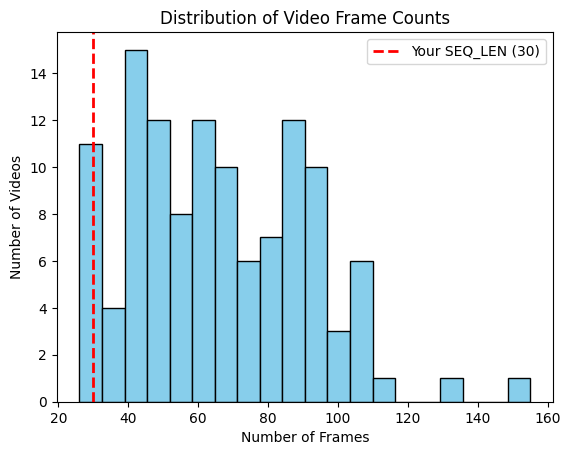

In [9]:
plt.hist(metadata_df['num_frames'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Video Frame Counts')
plt.xlabel('Number of Frames')
plt.ylabel('Number of Videos')
plt.axvline(30, color='red', linestyle='dashed', linewidth=2, label='Your SEQ_LEN (30)')
plt.legend()
plt.show()

# ***Video Standardization***

In [10]:
def standardize_frames(frames, target_len=30):
    curr_len = len(frames)
    if curr_len == 0:
        return np.zeros((target_len, 258))

    if curr_len > target_len:
        indices = np.linspace(0, curr_len - 1, target_len).astype(int)
        standardized_frames = [frames[i] for i in indices]
    elif curr_len < target_len:
        standardized_frames = list(frames)
        last_frame = frames[-1]
        padding_size = target_len - curr_len
        for _ in range(padding_size):
            standardized_frames.append(last_frame)
    else:
        standardized_frames = frames
    return np.array(standardized_frames)

In [11]:
def plot_sampling_results(raw_keypoints_list, standardized_array, gloss):
    """Visualizes Temporal Alignment."""
    plt.figure(figsize=(12, 4))
    # Using index 0 (Nose/Pose) to show movement over time
    raw_movement = [f[0] for f in raw_keypoints_list]
    std_movement = [f[0] for f in standardized_array]

    plt.plot(raw_movement, 'ro-', alpha=0.4, label=f"Original ({len(raw_movement)} frames)")
    plt.plot(std_movement, 'b.-', label=f"Standardized ({SEQ_LEN} frames)")
    plt.title(f"Temporal Standardization for Gloss: '{gloss}'")
    plt.ylabel("Normalized X-Coordinate")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

In [12]:
def visualize_sample_frame(video_path, frame_number=10):
    """Shows MediaPipe skeleton overlay on actual frame."""
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    success, image = cap.read()

    if success:
        with mp_holistic.Holistic() as holistic:
            results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
            mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
            mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
            print(f"Visualizing Frame {frame_number}:")
            cv2_imshow(image)
    cap.release()

# ***Spatial Preprocessing: Anchor-Based Normalization***

In [13]:
def extract_normalized_keypoints(results):
    """Spatial Preprocessing: Anchor-Based Normalization (Shoulders and Wrists)."""
    if results.pose_landmarks:
        pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark])
        mid_shoulder = (pose[11, :2] + pose[12, :2]) / 2
        pose[:, :2] -= mid_shoulder
        pose_feat = pose.flatten()
    else:
        pose_feat = np.zeros(33 * 4)

    def normalize_hand(hand_landmarks):
        if hand_landmarks:
            h_coords = np.array([[res.x, res.y, res.z] for res in hand_landmarks.landmark])
            h_coords[:, :2] -= h_coords[0, :2]
            return h_coords.flatten()
        return np.zeros(21 * 3)

    lh_feat = normalize_hand(results.left_hand_landmarks)
    rh_feat = normalize_hand(results.right_hand_landmarks)

    return np.concatenate([pose_feat, lh_feat, rh_feat])

# ***Hand Cropping & Bounding Box Scaling***

In [30]:
def get_hand_bounding_box(hand_landmarks, image_shape, padding=0.2):
    h, w, _ = image_shape
    x_coords = [lm.x for lm in hand_landmarks.landmark]
    y_coords = [lm.y for lm in hand_landmarks.landmark]

    xmin, xmax = min(x_coords), max(x_coords)
    ymin, ymax = min(y_coords), max(y_coords)

    width, height = xmax - xmin, ymax - ymin
    size = max(width, height) * (1 + padding)
    center_x, center_y = (xmin + xmax) / 2, (ymin + ymax) / 2

    left, top = int((center_x - size / 2) * w), int((center_y - size / 2) * h)
    right, bottom = int((center_x + size / 2) * w), int((center_y + size / 2) * h)

    return max(0, left), max(0, top), min(w, right), min(h, bottom)

In [31]:
def visualize_bounding_box(video_path, frame_number=10):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    success, frame = cap.read()
    if not success:
        print("Could not read frame.")
        cap.release()
        return

    h, w, _ = frame.shape
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    with mp_holistic.Holistic() as holistic:
        results = holistic.process(image_rgb)
        hand_landmarks = results.right_hand_landmarks
        if hand_landmarks:
            left, top, right, bottom = get_hand_bounding_box(hand_landmarks, frame.shape)
            cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 3)
            cv2.putText(frame, "Spatial Focus (Crop Area)", (left, top - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_holistic.HAND_CONNECTIONS)
            print(f"Bounding Box: Left={left}, Top={top}, Right={right}, Bottom={bottom}")
            cv2_imshow(frame)
        else:
            print("No hand detected in this frame to draw a box around.")
            cv2_imshow(frame)
    cap.release()

In [16]:
def visualize_normalization(hand_coords):
    """Checks if Anchor-Based Normalization centered the wrist at 0,0."""
    plt.figure(figsize=(5, 5))
    plt.scatter(hand_coords[:, 0], -hand_coords[:, 1], c='red')
    plt.axhline(0, color='black', alpha=0.3); plt.axvline(0, color='black', alpha=0.3)
    plt.title("Normalization Check (Wrist at 0,0)")
    plt.grid(True, alpha=0.2); plt.show()

def visualize_spatial_focus(hand_coords):
    """Simulates the 'Focused' view after cropping/scaling."""
    plt.figure(figsize=(5, 5))
    plt.scatter(hand_coords[:, 0], -hand_coords[:, 1], c='green')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title("Spatial Focus View (Tight Hand View)")
    plt.show()

In [46]:
def process_and_save_video(video_path, output_name='final_result.mp4'):
    cap = cv2.VideoCapture(video_path)

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))

    temp_raw = 'raw_output.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(temp_raw, fourcc, fps, (width, height))

    print("Processing frames...")
    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(image_rgb)

            # Detect Both Hands (Left and Right)
            for hand_landmarks in [results.left_hand_landmarks, results.right_hand_landmarks]:
                if hand_landmarks:
                    left, top, right, bottom = get_hand_bounding_box(hand_landmarks, frame.shape)
                    cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
                    mp_drawing.draw_landmarks(frame, hand_landmarks, mp_holistic.HAND_CONNECTIONS)

            out.write(frame)

    cap.release()
    out.release()

    print("Converting codec for playback...")
    os.system(f"ffmpeg -i {temp_raw} -vcodec libx264 -f mp4 -y {output_name} -loglevel quiet")
    print(f"Done! Saved as {output_name}")

def display_video(path):
    mp4 = open(path,'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f'<video width=600 controls><source src="{data_url}" type="video/mp4"></video>')

# ***Full Video to Keypoints Pipeline.***

In [33]:
def process_single_video(row, target_len=30):
    cap = cv2.VideoCapture(row['path'])
    raw_keypoints = []

    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        frame_idx = 1
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break

            # Start/End Frame logic
            if frame_idx >= row['start_frame'] and (row['end_frame'] == -1 or frame_idx <= row['end_frame']):
                image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = holistic.process(image_rgb)
                keypoints = extract_normalized_keypoints(results)
                raw_keypoints.append(keypoints)

            frame_idx += 1
    cap.release()

    final_sequence = standardize_frames(raw_keypoints, target_len)
    return final_sequence, raw_keypoints

In [34]:
# 1. Run Pipeline on Sample
sample_row = metadata_df.iloc[0]
test_data, raw_keypoints_for_plot = process_single_video(sample_row, SEQ_LEN)

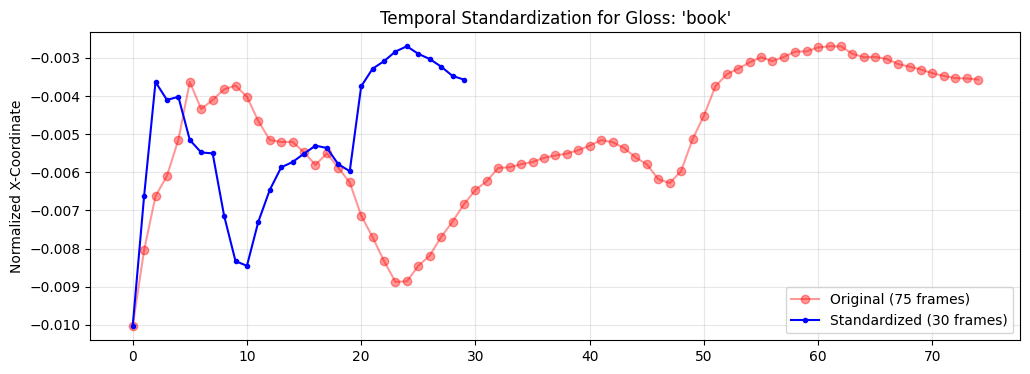

In [35]:
# 2. Test Temporal Visualization
plot_sampling_results(raw_keypoints_for_plot, test_data, sample_row['gloss'])

Visualizing Frame 10:


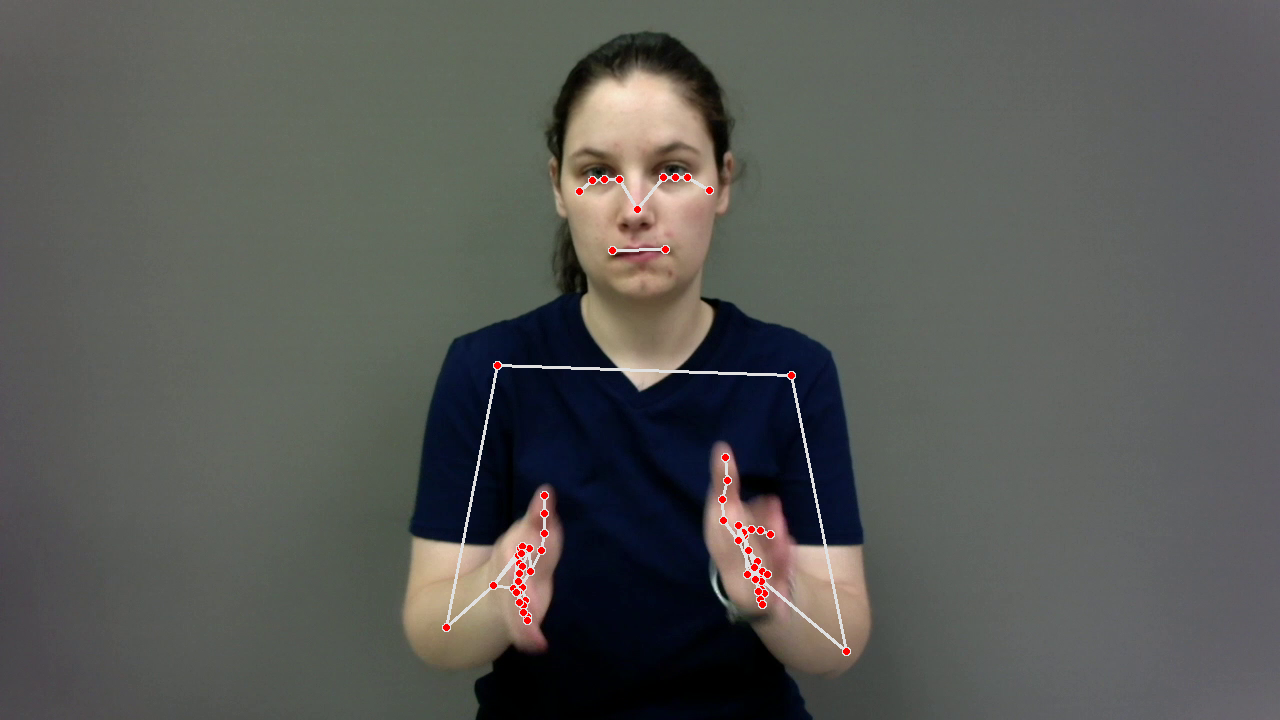

In [36]:
# 3. Test Skeleton Visualization
visualize_sample_frame(sample_row['path'], frame_number=10)

Bounding Box: Left=397, Top=482, Right=664, Bottom=633


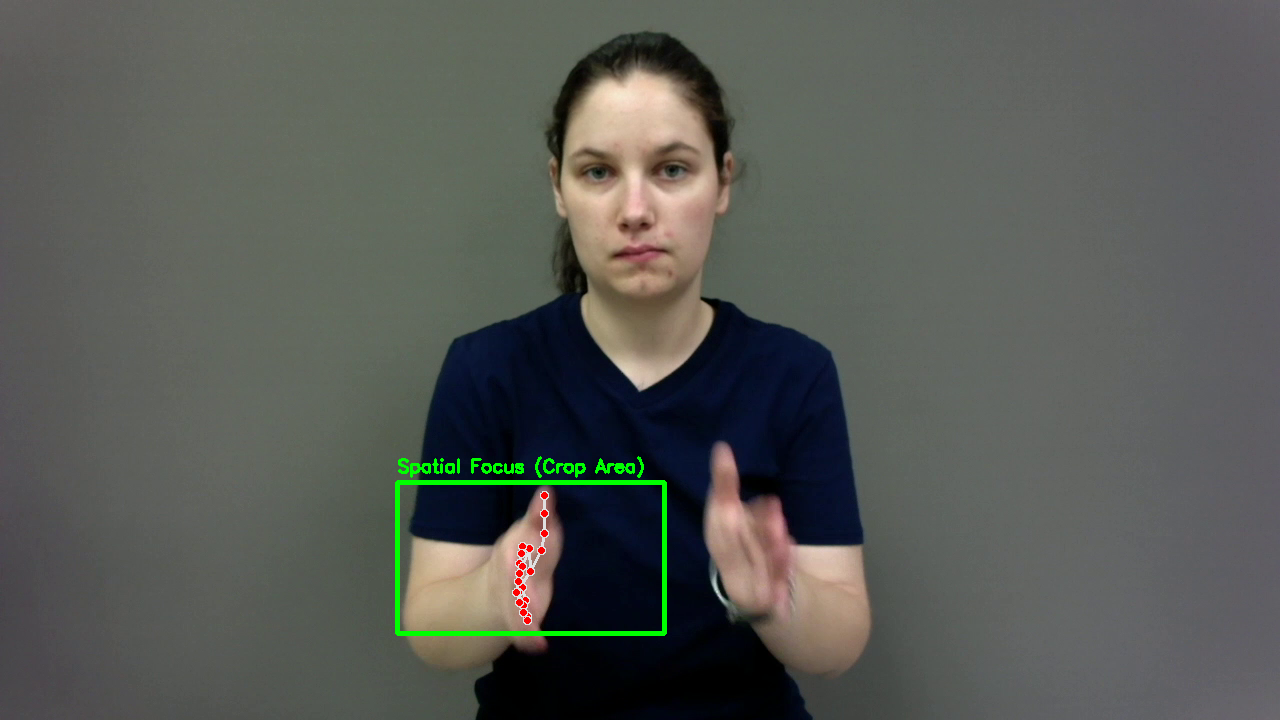

In [37]:
visualize_bounding_box(sample_row['path'], frame_number=10)

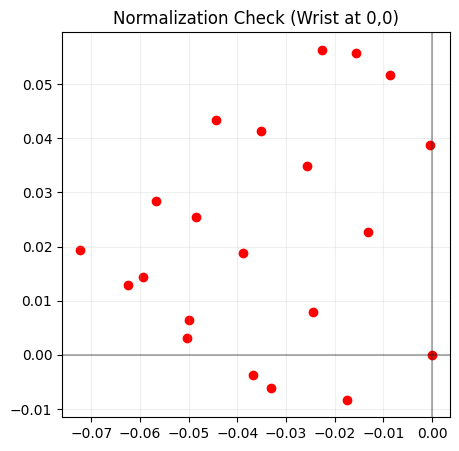

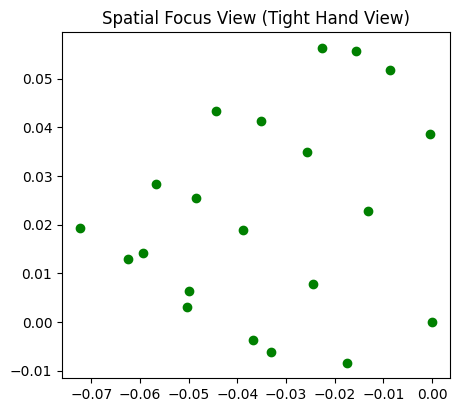

In [22]:
# 4. Test Spatial/Normalization Visualization
# Extract Left Hand (indices 132 to 195) from a random frame in our test_data
sample_lh = test_data[15][132:195].reshape(21, 3)
visualize_normalization(sample_lh)
visualize_spatial_focus(sample_lh)

In [54]:
input_path = '/content/wlasl-processed/videos/69241.mp4'
process_and_save_video(input_path, 'output_final.mp4')
display_video('output_final.mp4')

Processing frames...
Converting codec for playback...
Done! Saved as output_final.mp4


In [55]:
def augment_sequence(sequence):
    aug_seq = sequence.copy()
    angle = np.radians(np.random.uniform(-10, 10))
    c, s = np.cos(angle), np.sin(angle)
    rotation_matrix = np.array([[c, -s], [s, c]])

    # Apply to Pose (first 132 features, structured as x,y,z,v)
    for j in range(0, 132, 4):
        aug_seq[:, j:j+2] = np.dot(aug_seq[:, j:j+2], rotation_matrix)

    # Apply to Left Hand (next 63 features, structured as x,y,z)
    for j in range(132, 195, 3):
        aug_seq[:, j:j+2] = np.dot(aug_seq[:, j:j+2], rotation_matrix)

    # Apply to Right Hand (last 63 features, structured as x,y,z)
    for j in range(195, 258, 3):
        aug_seq[:, j:j+2] = np.dot(aug_seq[:, j:j+2], rotation_matrix)

    # 2. RANDOM SCALING (0.9x to 1.1x)
    scale = np.random.uniform(0.9, 1.1)
    aug_seq *= scale

    return aug_seq

In [56]:
def prepare_full_dataset(df, target_len=30):
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    # Create a mapping for Gloss to Integer (Labels)
    gloss_to_idx = {gloss: i for i, gloss in enumerate(selected_classes)}

    print(f"Starting Batch Processing for {len(df)} videos...")

    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            features, _ = process_single_video(row, target_len)
            label = gloss_to_idx[row['gloss']]

            if row['split'] == 'train':
                X_train.append(features)
                y_train.append(label)

                # 3. Apply AUGMENTATION to training data (Double the training size)
                aug_features = augment_sequence(features)
                X_train.append(aug_features)
                y_train.append(label)

            elif row['split'] == 'val':
                X_val.append(features)
                y_val.append(label)
            else:
                X_test.append(features)
                y_test.append(label)

        except Exception as e:
            print(f"⚠️ Error processing video {row['video_id']}: {e}")

    # Convert to Numpy Arrays
    return (np.array(X_train), np.array(y_train)), \
           (np.array(X_val), np.array(y_val)), \
           (np.array(X_test), np.array(y_test))

# RUN THE BATCH PROCESSOR
(x_train, y_train), (x_val, y_val), (x_test, y_test) = prepare_full_dataset(metadata_df)

np.save(os.path.join(OUTPUT_DIR, 'X_train.npy'), x_train)
np.save(os.path.join(OUTPUT_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(OUTPUT_DIR, 'X_val.npy'), x_val)
np.save(os.path.join(OUTPUT_DIR, 'y_val.npy'), y_val)
np.save(os.path.join(OUTPUT_DIR, 'X_test.npy'), x_test)
np.save(os.path.join(OUTPUT_DIR, 'y_test.npy'), y_test)

print("\nDATASET READY!")
print(f"Train samples: {len(x_train)} | Val samples: {len(x_val)} | Test samples: {len(x_test)}")

Starting Batch Processing for 119 videos...


100%|██████████| 119/119 [17:24<00:00,  8.78s/it]


DATASET READY!
Train samples: 170 | Val samples: 21 | Test samples: 13


In [57]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/WLASL_Final_Features"
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


In [58]:
import shutil

# This zips the entire 'WLASL_Final_Features' folder
shutil.make_archive('WLASL_Features_Backup', 'zip', '/content/WLASL_Final_Features')
print("✅ Folder zipped successfully!")

✅ Folder zipped successfully!


In [59]:
# Change '/content/drive/MyDrive/WLASL_Project/' to your desired Drive folder
!cp /content/WLASL_Features_Backup.zip /content/drive/MyDrive/WLASL_Project/
print("🚀 Zip file copied to Drive!")

🚀 Zip file copied to Drive!
